Setup:

In [1]:
import gc
import torch

torch.cuda.empty_cache()
gc.collect()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained('meta-llama/Llama-2-7b-hf')
model = AutoModelForCausalLM.from_pretrained('meta-llama/Llama-2-7b-hf', device_map="auto")
model.seqlen = model.config.max_position_embeddings

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [3]:
# from llm import find_layers

# find_layers(model)

# length = 0
# for name, param in model.named_parameters():
#     if 'proj' in name:
#         print(name, param.shape)
#         length += 1
# print(f'Matrix count: {length}')

In [4]:
model.hf_device_map

{'model.embed_tokens': 0,
 'model.layers.0': 0,
 'model.layers.1': 0,
 'model.layers.2': 0,
 'model.layers.3': 0,
 'model.layers.4': 0,
 'model.layers.5': 0,
 'model.layers.6': 0,
 'model.layers.7': 0,
 'model.layers.8': 0,
 'model.layers.9': 0,
 'model.layers.10': 0,
 'model.layers.11': 0,
 'model.layers.12': 0,
 'model.layers.13': 0,
 'model.layers.14': 0,
 'model.layers.15': 0,
 'model.layers.16': 1,
 'model.layers.17': 1,
 'model.layers.18': 1,
 'model.layers.19': 1,
 'model.layers.20': 1,
 'model.layers.21': 1,
 'model.layers.22': 1,
 'model.layers.23': 1,
 'model.layers.24': 1,
 'model.layers.25': 1,
 'model.layers.26': 1,
 'model.layers.27': 1,
 'model.layers.28': 1,
 'model.layers.29': 1,
 'model.layers.30': 1,
 'model.layers.31': 1,
 'model.norm': 1,
 'model.rotary_emb': 1,
 'lm_head': 1}

In [5]:
o_proj_weight = model.model.layers[14].mlp.up_proj.weight
# o_proj_weight = model.model.layers[8].self_attn.v_proj.weight
print(o_proj_weight.shape)   # torch.Size([1024, 4096])
print(o_proj_weight.device)
print(o_proj_weight.dtype)
print(o_proj_weight)

k_proj_weight = model.model.layers[5].self_attn.k_proj.weight
print(k_proj_weight.shape)   # torch.Size([1024, 4096])
print(k_proj_weight.device)
print(k_proj_weight.dtype)
print(k_proj_weight)

mlp_down_weight = model.model.layers[8].mlp.down_proj.weight
# print(mlp_up_weight.shape)   # torch.Size([14336, 4096])
# print(mlp_up_weight.device)
# print(mlp_up_weight.dtype)
# print(mlp_up_weight)


torch.Size([11008, 4096])
cuda:0
torch.float16
Parameter containing:
tensor([[ 1.1215e-03,  1.0376e-02,  1.9409e-02,  ..., -2.6489e-02,
          8.1177e-03,  7.7820e-03],
        [ 2.6855e-02,  1.4099e-02, -2.8320e-02,  ...,  1.3916e-02,
          2.1362e-02,  1.4526e-02],
        [ 1.6093e-06,  3.9368e-03,  3.2227e-02,  ..., -1.6022e-03,
          1.9653e-02, -5.4932e-03],
        ...,
        [-1.4832e-02,  7.7209e-03, -4.7119e-02,  ..., -7.8735e-03,
         -5.0659e-03, -4.3640e-03],
        [-2.7466e-02,  2.5635e-02, -6.1340e-03,  ..., -1.3611e-02,
          2.3438e-02, -1.6235e-02],
        [ 5.5237e-03,  2.5757e-02,  1.1597e-02,  ...,  1.1902e-02,
         -1.3733e-02,  7.4463e-03]], device='cuda:0', dtype=torch.float16,
       requires_grad=True)
torch.Size([4096, 4096])
cuda:0
torch.float16
Parameter containing:
tensor([[-0.0145,  0.0295,  0.0062,  ...,  0.0155, -0.0024, -0.0049],
        [ 0.0015, -0.0009, -0.0298,  ...,  0.0187, -0.0081,  0.0344],
        [-0.0082, -0.0168,

In [ ]:
a = [18.32101058959961, 24.502410888671875, 30.280719757080078, 31.046875, 40.66182327270508]
b = [19.601356506347656, 26.245691299438477, 32.451053619384766, 33.03125, 43.59768295288086]
c = [20.682111740112305, 27.63224220275879, 34.15394592285156, 35.3125, 45.8751335144043]

lists = [list(x) for x in zip(a, b, c)]
for i in lists:
    print(i)

[18.32101058959961, 19.601356506347656, 20.682111740112305]
[24.502410888671875, 26.245691299438477, 27.63224220275879]
[30.280719757080078, 32.451053619384766, 34.15394592285156]
[31.046875, 33.03125, 35.3125]
[40.66182327270508, 43.59768295288086, 45.8751335144043]


Tests:

In [6]:
from test_dbsf import *

In [7]:
# f = test_double_block_sparse(matrix=o_proj_weight, total_sp=0.5, b_bias=0.5, mid_dim_scale=2)

In [8]:
a = test_double_sparse(matrix=o_proj_weight, total_sp=0.5, b_bias=0.5, mid_dim_scale=1)

Frobenius pre-finalization:  19.601356506347656
Frobenius norm: 19.601356506347656
A: tensor([[ 0.0000, -0.0000,  0.0000,  0.0000],
        [ 0.0245,  0.0144, -0.0136, -0.0583],
        [ 0.0000,  0.0000,  0.0358, -0.0000],
        [-0.0000,  0.0000, -0.0000, -0.0000]])
B: tensor([[ 0.8808, -0.0000,  0.0312,  0.0000],
        [ 0.0000,  0.8678,  0.0000,  0.0000],
        [-0.0000, -0.0146,  0.8991, -0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.8835]])
A.size() = torch.Size([11008, 4096])
B.size() = torch.Size([4096, 4096])
AB: tensor([[ 7.3285e-04,  8.9921e-03,  1.3932e-02,  ..., -2.7254e-02,
          7.8428e-03,  5.6433e-03],
        [ 2.8127e-02,  1.4713e-02, -2.8085e-02,  ...,  1.1723e-02,
          1.9170e-02,  1.6008e-02],
        [-2.5525e-03,  2.6586e-03,  3.2172e-02,  ..., -1.9200e-04,
          1.9559e-02, -6.8835e-03],
        ...,
        [-1.2187e-02,  5.1796e-03, -4.9239e-02,  ..., -3.5947e-03,
         -8.4462e-05, -1.2072e-03],
        [-2.9137e-02,  2.5290e-02, -5.2

In [9]:
b = test_hybrid(matrix=o_proj_weight, asp=0.25, bsp=0.25)

Frobenius pre-finalization:  21.150686264038086
Frobenius norm: 21.150686264038086
A: tensor([[ 0.0000,  0.0000,  0.0161,  0.0123],
        [ 0.0454,  0.0000, -0.0177, -0.0620],
        [ 0.0000,  0.0000,  0.0270, -0.0000],
        [ 0.0000,  0.0000, -0.0000, -0.0000]])
B: tensor([[ 0.8783,  0.0000,  0.0116,  0.0000],
        [ 0.0064,  0.8835,  0.0000,  0.0000],
        [ 0.0000, -0.0000,  0.8842, -0.0190],
        [-0.0000,  0.0212,  0.0000,  0.8938]])
A.size() = torch.Size([11008, 4096])
B.size() = torch.Size([4096, 4096])
AB: tensor([[-0.0011,  0.0085,  0.0160,  ..., -0.0270,  0.0076,  0.0098],
        [ 0.0284,  0.0080, -0.0269,  ...,  0.0098,  0.0229,  0.0093],
        [-0.0004,  0.0011,  0.0319,  ..., -0.0023,  0.0180,  0.0017],
        ...,
        [-0.0154,  0.0077, -0.0451,  ..., -0.0019, -0.0084, -0.0004],
        [-0.0284,  0.0251, -0.0070,  ..., -0.0154,  0.0192, -0.0175],
        [ 0.0100,  0.0282,  0.0068,  ...,  0.0124, -0.0126,  0.0105]])
Input matrix was: tensor([[ 1.

In [10]:
c = test_2to4_A_B(matrix=o_proj_weight, sp=0.25, mid_dim_scale=1)

Frobenius pre-finalization:  26.245691299438477
Frobenius norm: 26.245691299438477
A: tensor([[ 0.0350, -0.0000,  0.0000,  0.0518],
        [ 0.0000,  0.0000, -0.0000, -0.0000],
        [ 0.0000, -0.0352,  0.0000, -0.0230],
        [ 0.0259, -0.0188,  0.0000,  0.0000]])
B: tensor([[-0.0000,  0.0000,  0.0000,  0.0000],
        [-0.0000, -0.0000,  0.0000, -0.0000],
        [ 0.0000, -0.0000, -0.0178,  0.0163],
        [-0.0200, -0.0100,  0.0000,  0.0000]])
A.size() = torch.Size([11008, 4096])
B.size() = torch.Size([4096, 4096])
AB: tensor([[ 0.0013,  0.0089,  0.0162,  ..., -0.0206,  0.0017,  0.0066],
        [ 0.0248,  0.0139, -0.0283,  ...,  0.0080,  0.0174,  0.0189],
        [-0.0012, -0.0025,  0.0322,  ...,  0.0023,  0.0160, -0.0040],
        ...,
        [-0.0155,  0.0068, -0.0471,  ...,  0.0003, -0.0022, -0.0033],
        [-0.0245,  0.0263, -0.0064,  ..., -0.0082,  0.0191, -0.0152],
        [ 0.0120,  0.0269,  0.0027,  ...,  0.0091, -0.0070,  0.0075]])
Input matrix was: tensor([[ 1.

In [11]:
d = test_1x2_2x1(matrix=o_proj_weight, sp=0.25, mid_dim_scale=1)

Frobenius pre-finalization:  32.451053619384766
Frobenius norm: 32.451053619384766
A: tensor([[ 0.0054, -0.0000, -0.0000,  0.0011],
        [ 0.0457, -0.0000, -0.0000, -0.0492],
        [ 0.0000,  0.0000,  0.0000, -0.0000],
        [-0.0000, -0.0000, -0.0000,  0.0000]])
B: tensor([[ 0.8354,  0.0201,  0.0277, -0.0142],
        [-0.0206,  0.7870,  0.0000, -0.0000],
        [ 0.0000, -0.0000,  0.8124,  0.0059],
        [-0.0000,  0.0000, -0.0167,  0.8254]])
A.size() = torch.Size([11008, 4096])
B.size() = torch.Size([4096, 4096])
AB: tensor([[ 0.0033,  0.0062,  0.0250,  ..., -0.0338,  0.0065,  0.0110],
        [ 0.0280,  0.0116, -0.0267,  ...,  0.0059,  0.0239,  0.0151],
        [-0.0064,  0.0011,  0.0286,  ...,  0.0059,  0.0168, -0.0065],
        ...,
        [-0.0085,  0.0136, -0.0448,  ..., -0.0092,  0.0004, -0.0016],
        [-0.0279,  0.0244, -0.0070,  ..., -0.0114,  0.0270, -0.0089],
        [ 0.0048,  0.0303,  0.0176,  ...,  0.0098, -0.0157,  0.0046]])
Input matrix was: tensor([[ 1.

In [12]:
e = test_mag_prune(matrix=o_proj_weight, sp=0.5)

Frobenius norm: 33.03125
AB: tensor([[ 0.0000,  0.0000,  0.0194,  ..., -0.0265,  0.0000,  0.0000],
        [ 0.0269,  0.0141, -0.0283,  ...,  0.0139,  0.0214,  0.0145],
        [ 0.0000,  0.0000,  0.0322,  ..., -0.0000,  0.0197, -0.0000],
        ...,
        [-0.0148,  0.0000, -0.0471,  ..., -0.0000, -0.0000, -0.0000],
        [-0.0275,  0.0256, -0.0000,  ..., -0.0136,  0.0234, -0.0162],
        [ 0.0000,  0.0258,  0.0000,  ...,  0.0000, -0.0137,  0.0000]],
       dtype=torch.float16)
Input matrix was: Parameter containing:
tensor([[ 1.1215e-03,  1.0376e-02,  1.9409e-02,  ..., -2.6489e-02,
          8.1177e-03,  7.7820e-03],
        [ 2.6855e-02,  1.4099e-02, -2.8320e-02,  ...,  1.3916e-02,
          2.1362e-02,  1.4526e-02],
        [ 1.6093e-06,  3.9368e-03,  3.2227e-02,  ..., -1.6022e-03,
          1.9653e-02, -5.4932e-03],
        ...,
        [-1.4832e-02,  7.7209e-03, -4.7119e-02,  ..., -7.8735e-03,
         -5.0659e-03, -4.3640e-03],
        [-2.7466e-02,  2.5635e-02, -6.1340e-

In [13]:
g = test_double_block_sparse(matrix=o_proj_weight, total_sp=0.5, b_bias=0.5, mid_dim_scale=1)

Frobenius pre-finalization:  43.59768295288086
Frobenius norm: 43.59768295288086
A: tensor([[ 0.0000,  0.0000, -0.0021,  0.0167],
        [ 0.0000,  0.0000, -0.0029, -0.0408],
        [-0.0000, -0.0000,  0.0000, -0.0000],
        [-0.0000, -0.0000,  0.0000,  0.0000]])
B: tensor([[ 0.7261,  0.0018, -0.0000,  0.0000],
        [-0.0099,  0.7103,  0.0000,  0.0000],
        [ 0.0000, -0.0000,  0.7354, -0.0025],
        [-0.0000,  0.0000, -0.0169,  0.7696]])
A.size() = torch.Size([11008, 4096])
B.size() = torch.Size([4096, 4096])
AB: tensor([[-0.0063,  0.0033,  0.0156,  ..., -0.0189,  0.0020,  0.0134],
        [ 0.0238,  0.0073, -0.0211,  ...,  0.0090,  0.0090,  0.0150],
        [ 0.0028,  0.0129,  0.0213,  ..., -0.0061,  0.0177, -0.0097],
        ...,
        [-0.0238,  0.0131, -0.0421,  ...,  0.0011, -0.0068, -0.0137],
        [-0.0213,  0.0269, -0.0120,  ..., -0.0102,  0.0236, -0.0198],
        [ 0.0095,  0.0275,  0.0043,  ..., -0.0066, -0.0150,  0.0071]])
Input matrix was: tensor([[ 1.12

In [14]:
# h = test_2to4_A_B(matrix=o_proj_weight, sp=0.5, mid_dim_scale=0.5)

In [15]:
print(f"{[a, c, d, e, g]}")

[19.601356506347656, 26.245691299438477, 32.451053619384766, 33.03125, 43.59768295288086]


Output:

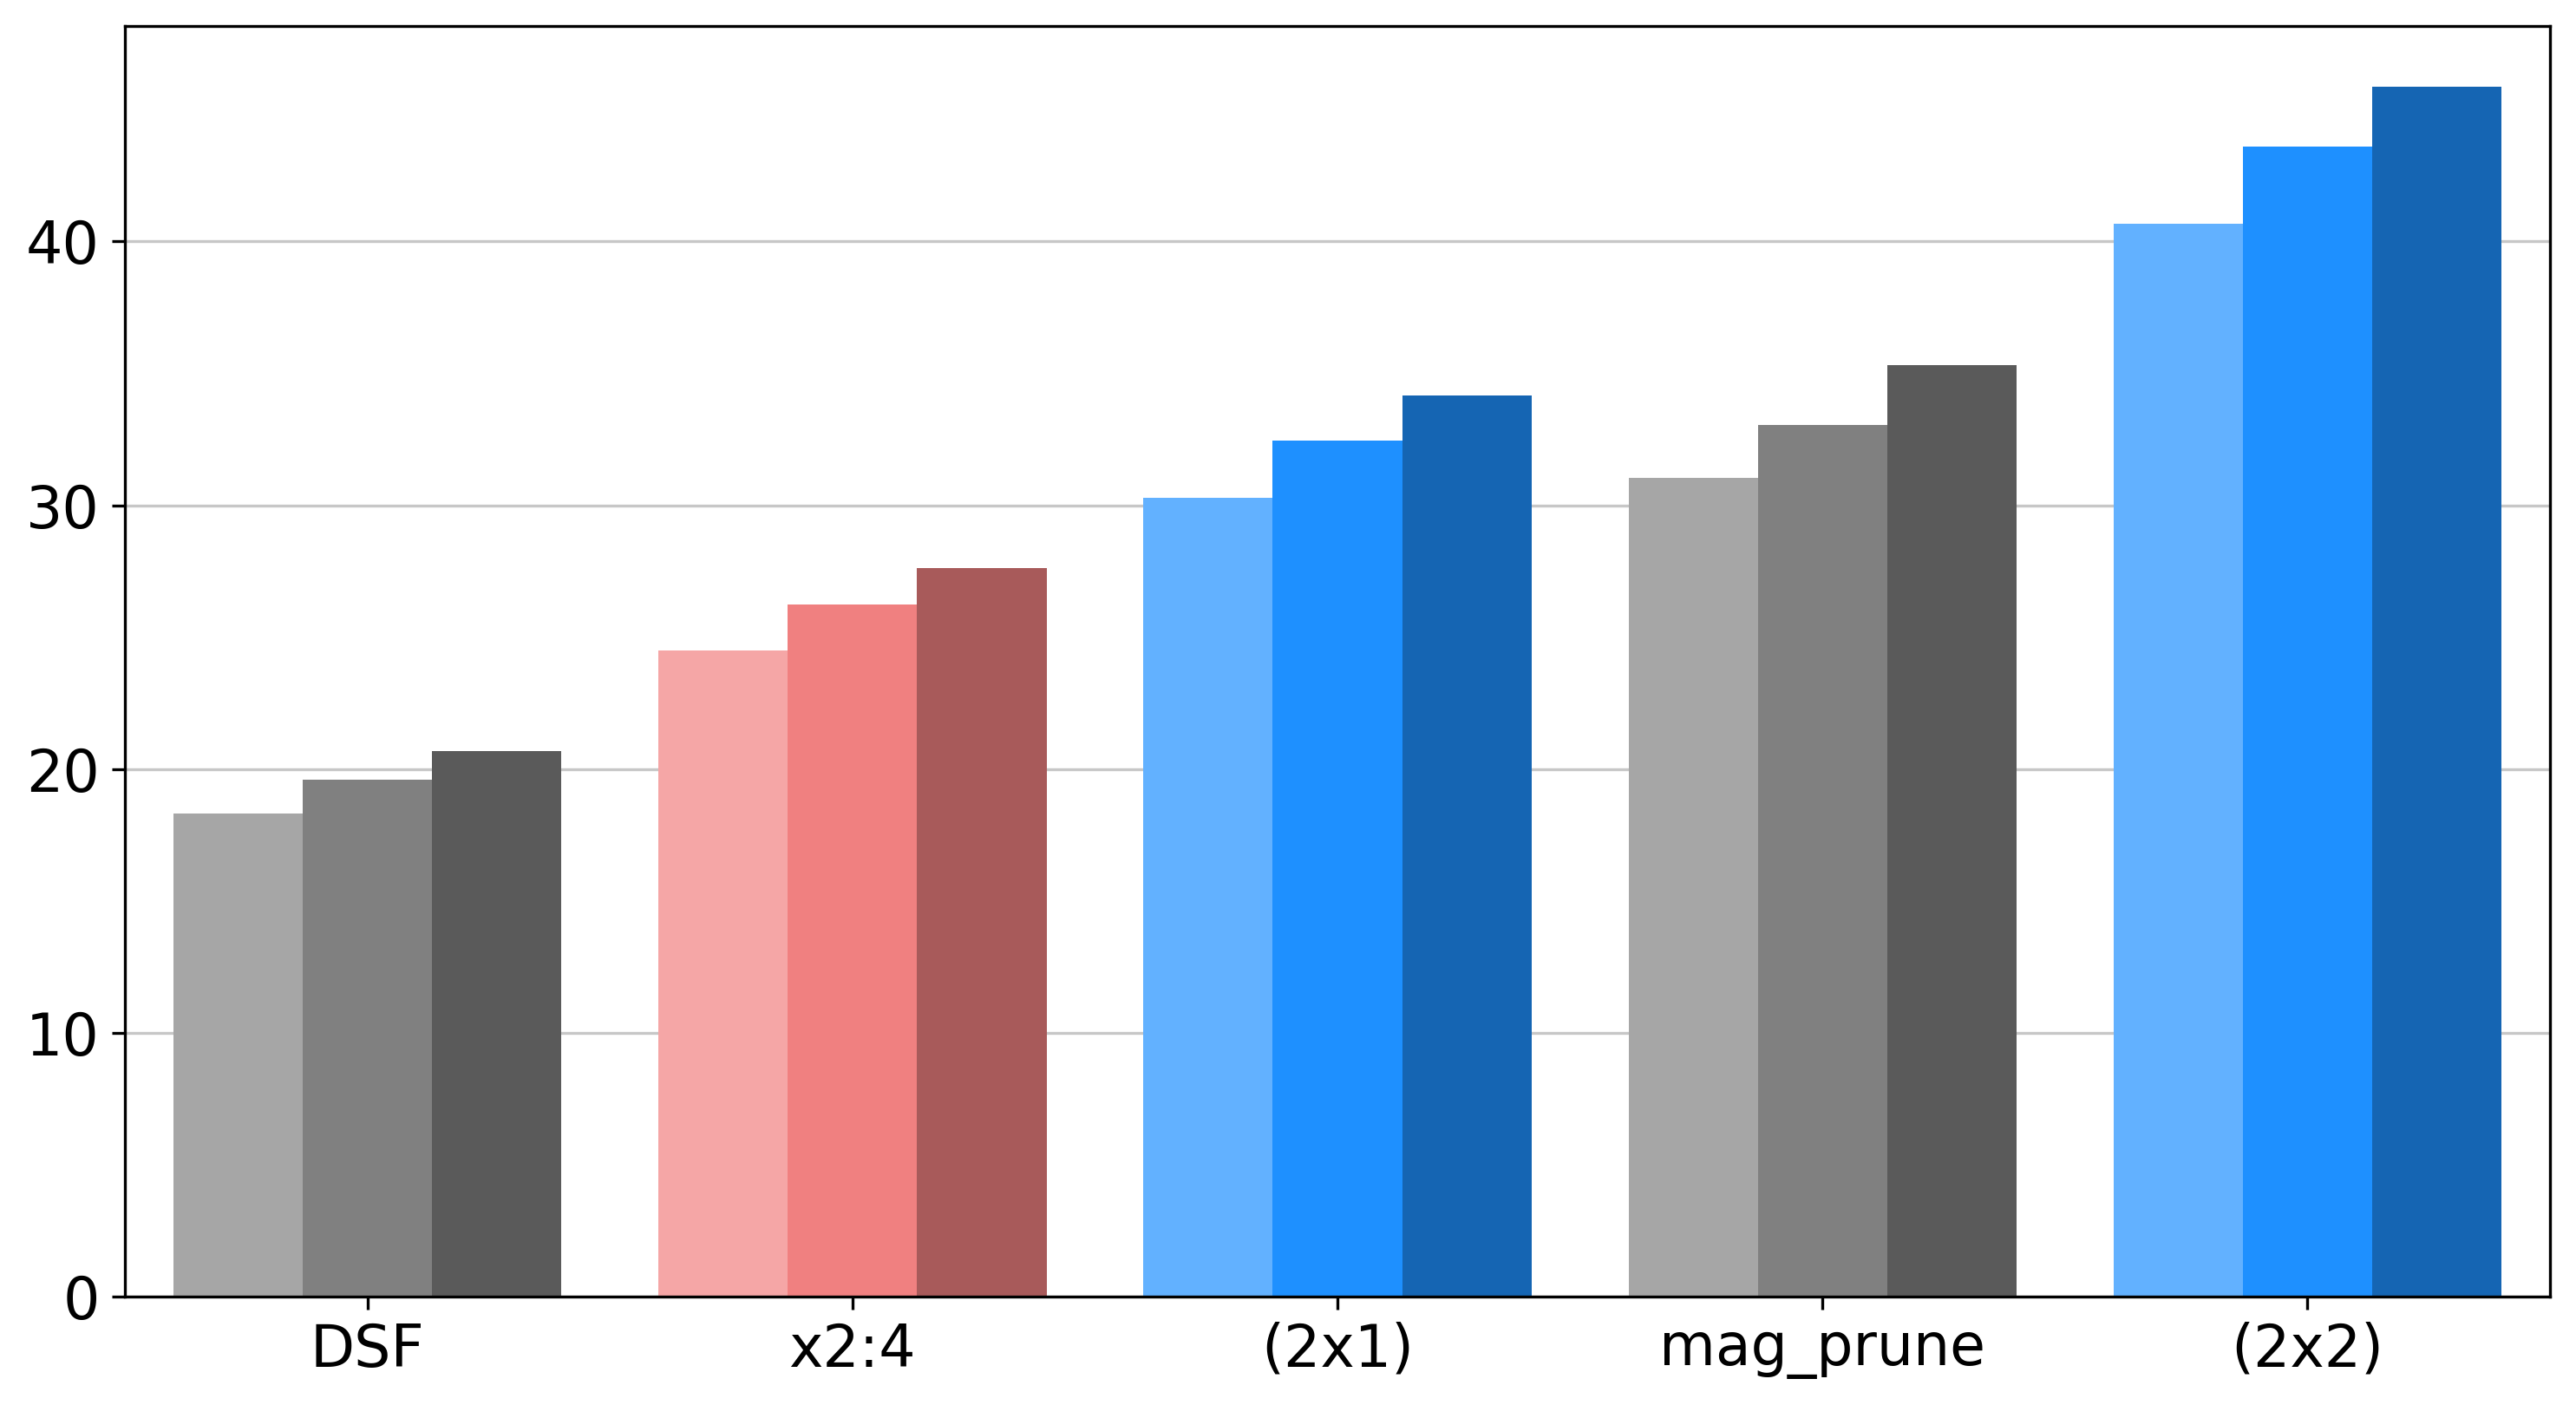

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.colors as mcolors

sns.reset_orig()
from matplotlib import rcParams
rcParams['figure.figsize'] = 10, 5.5
rcParams['figure.dpi'] = 300

def adjust_lightness(color, amount=0.5):
    try:
        c = mcolors.to_rgb(color)
        if amount > 1:
            return [min(1, x + (1 - x) * (amount - 1)) for x in c]
        else:
            return [x * amount for x in c]
    except:
        return color
    
raw_data = {
    'DSF': [18.32101058959961, 19.601356506347656, 20.682111740112305],
    'x2:4': [24.502410888671875, 26.245691299438477, 27.63224220275879],
    '(2x1)': [30.280719757080078, 32.451053619384766, 34.15394592285156],
    'mag_prune': [31.046875, 33.03125, 35.3125],
    '(2x2)': [40.66182327270508, 43.59768295288086, 45.8751335144043],
}

plot_data = []
for label, values in raw_data.items():
    for i, (val, sub_label) in enumerate(zip(values, ['vproj', 'oproj', 'kproj'])):
        plot_data.append({"cat": label, "val": val, "subbar": sub_label})
df = pd.DataFrame(plot_data)

category_colors = ["gray", "lightcoral", "dodgerblue", "gray", "dodgerblue"]
color_dict = dict(zip(raw_data.keys(), category_colors))

fig, ax = plt.subplots()
ax.set_axisbelow(True)
bars = sns.barplot(
    data=df, x="cat", y="val", hue="subbar", 
    palette=["gray"]*3, edgecolor="none", gap=0 
)

num_categories = len(raw_data)
for i, patch in enumerate(ax.patches):
    cat_index = i % num_categories
    sub_index = i // num_categories
    
    base_color = color_dict[list(raw_data.keys())[cat_index]]
    
    if sub_index == 0:
        final_color = adjust_lightness(base_color, 1.3)
    elif sub_index == 1:
        final_color = base_color
    else:
        final_color = adjust_lightness(base_color, 0.7)
        
    patch.set_facecolor(final_color)

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.grid(axis='y', linestyle='-', alpha=0.7)
ax.get_legend().remove()
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

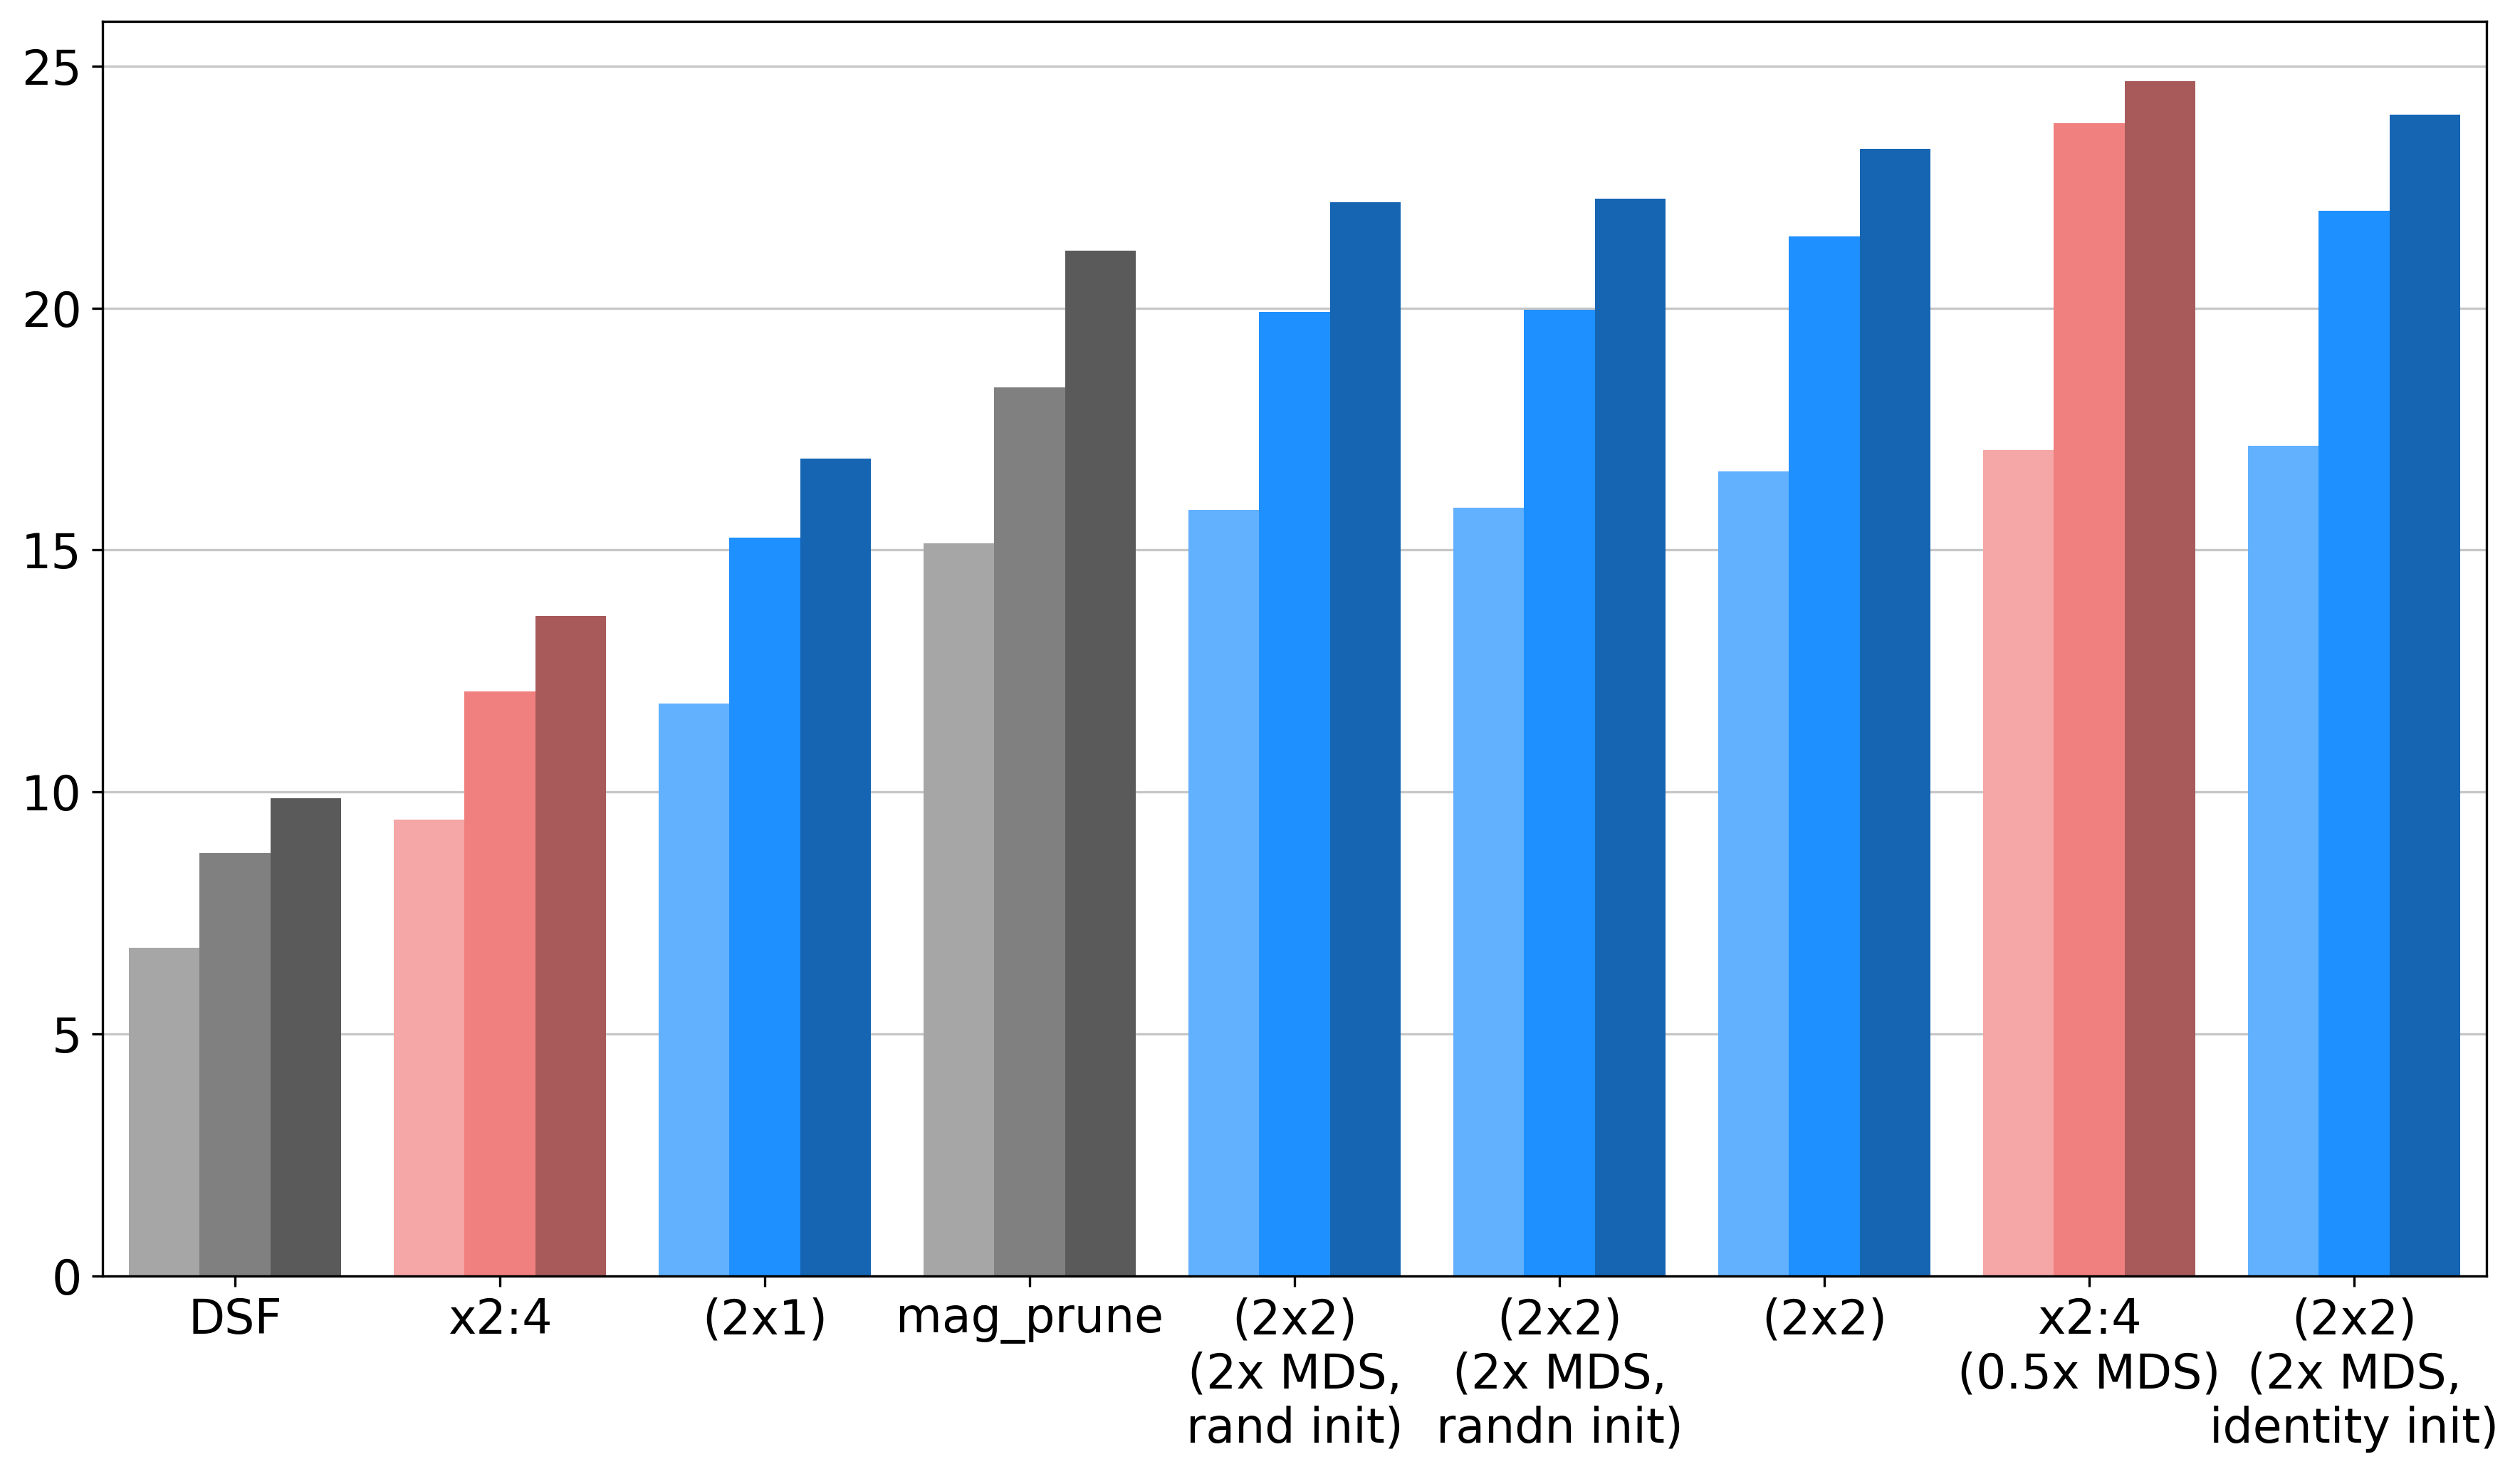

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.colors as mcolors

sns.reset_orig()
from matplotlib import rcParams
rcParams['figure.figsize'] = 12, 7
rcParams['figure.dpi'] = 300

def adjust_lightness(color, amount=0.5):
    try:
        c = mcolors.to_rgb(color)
        if amount > 1:
            return [min(1, x + (1 - x) * (amount - 1)) for x in c]
        else:
            return [x * amount for x in c]
    except:
        return color

raw_data = {
    'DSF': [6.7793869972229, 8.737, 9.879196166992188],
    'x2:4': [9.42798137664795, 12.083536148071289, 13.633490562438965],
    '(2x1)': [11.825608253479004, 15.2601957321167, 16.891361236572266],
    'mag_prune': [15.140625, 18.359375, 21.1875],
    '(2x2)\n(2x MDS,\nrand init)': [15.834587097167969, 19.923006057739258, 22.186927795410156],
    '(2x2)\n(2x MDS,\nrandn init)': [15.88033676147461, 19.971500396728516, 22.25733757019043],
    '(2x2)': [16.63092803955078, 21.48093032836914, 23.295005798339844],
    '(2x2)\n(2x MDS,\nidentity init)': [17.152555465698242, 22.014415740966797, 23.997758865356445],
    'x2:4\n(0.5x MDS)': [17.066184997558594, 23.825986862182617, 24.689355850219727],
}

plot_data = []
for label, values in raw_data.items():
    for i, (val, sub_label) in enumerate(zip(values, ['vproj', 'oproj', 'kproj'])):
        plot_data.append({"cat": label, "val": val, "subbar": sub_label})
df = pd.DataFrame(plot_data)

category_colors = ["gray", "lightcoral", "dodgerblue", "gray", "dodgerblue", "dodgerblue", "dodgerblue", "dodgerblue", "lightcoral"]
color_dict = dict(zip(raw_data.keys(), category_colors))

fig, ax = plt.subplots()
ax.set_axisbelow(True)
bars = sns.barplot(
    data=df, x="cat", y="val", hue="subbar", 
    palette=["gray"]*3, edgecolor="none", gap=0 
)

num_categories = len(raw_data)
for i, patch in enumerate(ax.patches):
    cat_index = i % num_categories
    sub_index = i // num_categories
    
    base_color = color_dict[list(raw_data.keys())[cat_index]]
    
    if sub_index == 0:
        final_color = adjust_lightness(base_color, 1.3)
    elif sub_index == 1:
        final_color = base_color
    else:
        final_color = adjust_lightness(base_color, 0.7)
        
    patch.set_facecolor(final_color)

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.grid(axis='y', linestyle='-', alpha=0.7)
ax.get_legend().remove()
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

Cleanup:

In [18]:
import gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()